# Barotropic Vorticity Equation: Visualization Guide

This notebook documents standard visualization techniques for barotropic model output.
All data is synthetically generated so each technique can be studied in isolation.
The same code applies directly to Isca NetCDF output loaded via xarray.

The barotropic vorticity equation (BVE) on a rotating sphere is:

$$\frac{D(\zeta + f)}{Dt} = F + D$$

where $\zeta$ is relative vorticity, $f = 2\Omega\sin\phi$ is the Coriolis parameter,
$F$ is external stirring, and $D$ is dissipation.

## Organization

Visualizations are grouped into three categories by how general they are:

| Part | Scope | Applies to |
|---|---|---|
| 1 | BVE-specific | Barotropic vorticity equation only |
| 2 | Fluid dynamics general | Any fluid system (Navier-Stokes, shallow water, etc.) |
| 3 | PDE general | Any PDE-based or learned operator model |

## Setup: Synthetic Data

### Grid

A T42-resolution lat-lon grid with $64 \times 128$ points covering
$[-87.5^\circ, 87.5^\circ]$ in latitude and $[0^\circ, 360^\circ)$ in longitude.

### Base State: Zonal Jet

The background zonal wind is a pair of symmetric Gaussian jets at $\pm 45^\circ$:

$$U_{\text{mean}}(\phi) = U_0 \left[
  \exp\!\left(-\frac{(\phi - 45^\circ)^2}{2\sigma^2}\right) +
  \exp\!\left(-\frac{(\phi + 45^\circ)^2}{2\sigma^2}\right)
\right]$$

with $U_0 = 25$ m/s and $\sigma = 15^\circ$.

### Broadband Vorticity (Initial Condition)

The initial vorticity field is generated in Fourier space with a $k^{-3}$ energy spectrum.
For $E(k) \sim k^{-3}$, the spectral amplitude of vorticity must scale as $|\hat{\zeta}_k| \sim k^{-1/2}$:

$$\hat{\zeta}_k = k^{-1/2} (a_k + i b_k), \quad a_k, b_k \sim \mathcal{N}(0,1)$$

The result is inverse-transformed to physical space and smoothed in latitude with a
Gaussian filter to produce coherent meridional structure.

### Streamfunction via Spectral Laplacian Inversion

The streamfunction $\psi$ is obtained by solving $\nabla^2 \psi = \zeta$ spectrally
using a doubly-periodic Cartesian approximation:

$$\hat{\psi}_k = -\hat{\zeta}_k / k^2$$

Physical wavenumbers are computed from the grid spacing
$\Delta x = a \Delta\lambda$ and $\Delta y = a \Delta\phi$.

### Winds from Streamfunction

Both wind components are derived consistently from $\psi$:

$$u = -\frac{1}{a} \frac{\partial \psi}{\partial \phi}, \qquad
  v =  \frac{1}{a \cos\phi} \frac{\partial \psi}{\partial \lambda}$$

The full zonal wind is $U = U_{\text{mean}} + u$.

### Time Integration

The vorticity equation is integrated forward in time using forward Euler with a
6-hour timestep. Snapshots are saved every 7 days for $\text{NTIME} = 12$ segments:

$$\zeta^{n+1} = \zeta^n - \Delta t \left( u \frac{\partial \zeta}{\partial x} + v \frac{\partial \zeta}{\partial y} \right) - \nu \Delta t (\zeta^n - \tilde{\zeta}^n)$$

where $\tilde{\zeta}$ is a lightly Gaussian-smoothed vorticity (hyperdiffusion term
to suppress small-scale spectral buildup from the forward Euler scheme).
After each 7-day segment the streamfunction is re-inverted and winds are updated.

### Prediction Field

A synthetic model prediction is created by applying a Gaussian blur
(sigma = 1.5 grid points) to the true vorticity and adding small random noise.
This mimics the over-smoothing bias common in learned operators and is used
to demonstrate error and spectral diagnostics.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

plt.rcParams['figure.dpi'] = 100

# --- Grid ---
NLAT  = 64
NLON  = 128
NTIME = 12

lat     = np.linspace(-87.5, 87.5, NLAT)
lon     = np.linspace(0.0, 360.0 - 360.0 / NLON, NLON)
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)
LON, LAT = np.meshgrid(lon_rad, lat_rad)

EARTH_RADIUS = 6.371e6  # m
OMEGA        = 7.292e-5  # rad/s
CORIOLIS     = 2.0 * OMEGA * np.sin(LAT)

dlat    = lat_rad[1] - lat_rad[0]
dlon    = lon_rad[1] - lon_rad[0]
cos_lat = np.cos(LAT).clip(1e-6)

rng = np.random.default_rng(42)

# --- Background zonal jet ---
JET_LAT   = np.deg2rad(45.0)
JET_WIDTH = np.deg2rad(15.0)
JET_SPEED = 25.0  # m/s

U_MEAN = JET_SPEED * (
    np.exp(-((LAT - JET_LAT) ** 2) / (2.0 * JET_WIDTH ** 2)) +
    np.exp(-((LAT + JET_LAT) ** 2) / (2.0 * JET_WIDTH ** 2))
)

# --- Broadband vorticity with k^{-3} energy spectrum ---
# E(k) ~ k^{-3}  =>  |psi_k|^2 ~ k^{-5}  =>  |zeta_k|^2 = k^4 |psi_k|^2 ~ k^{-1}
# So spectral amplitude of zeta_k ~ k^{-1/2}

nk = NLON // 2 + 1
k_zonal = np.arange(nk, dtype=float)
k_zonal[0] = 1.0
spectral_amp = k_zonal ** (-0.5)
spectral_amp[0] = 0.0  # zero mean

def make_broadband_vorticity(seed, scale=5e-5):
    r = np.random.default_rng(seed)
    coeffs = (r.standard_normal((NLAT, nk)) + 1j * r.standard_normal((NLAT, nk))) * spectral_amp[None, :]
    vor = np.fft.irfft(coeffs, n=NLON, axis=1)
    # Smooth in latitude for coherent meridional structure
    for i in range(NLON):
        vor[:, i] = gaussian_filter(vor[:, i], sigma=3)
    return vor * scale / (vor.std() + 1e-20)

# --- Spectral Laplacian inversion: solve nabla^2 psi = zeta ---
# Uses doubly-periodic Cartesian approximation.
# Physical grid spacing (mid-latitude approximation for x)
DX = EARTH_RADIUS * dlon  # m
DY = EARTH_RADIUS * dlat  # m

kx_phys = np.fft.rfftfreq(NLON) * (2.0 * np.pi / DX)  # rad/m
ky_phys = np.fft.fftfreq(NLAT)  * (2.0 * np.pi / DY)  # rad/m
KX_PHYS, KY_PHYS = np.meshgrid(kx_phys, ky_phys)
K2_PHYS = KX_PHYS ** 2 + KY_PHYS ** 2
K2_PHYS[0, 0] = 1.0  # avoid divide by zero

def invert_for_psi(vor):
    """Solve nabla^2 psi = zeta spectrally. Returns psi in m^2/s."""
    vor_hat = np.fft.rfft2(vor)
    psi_hat = -vor_hat / K2_PHYS[:, :nk]
    psi_hat[0, 0] = 0.0  # zero mean streamfunction
    return np.fft.irfft2(psi_hat, s=(NLAT, NLON))

def winds_from_psi(psi):
    """Derive u = -dpsi/dy, v = dpsi/dx on the sphere."""
    u = -np.gradient(psi, dlat, axis=0) / EARTH_RADIUS
    v =  np.gradient(psi, dlon, axis=1) / (EARTH_RADIUS * cos_lat)
    return u, v

# --- Initial condition ---
VOR_0 = make_broadband_vorticity(seed=0)
PSI_0 = invert_for_psi(VOR_0)
U_PERT_0, V_0 = winds_from_psi(PSI_0)
U_FULL = U_MEAN + U_PERT_0

# --- Forward time integration of the BVE ---
# dzeta/dt = -(u dzeta/dx + v dzeta/dy)
# Forward Euler, 6-hour timestep, save snapshot every 7 days

DT_SIM   = 6.0 * 3600.0               # 6-hour timestep [s]
STEPS_7D = int(7.0 * 86400.0 / DT_SIM)  # steps per 7-day segment

def advect_step(vor, u, v, dt):
    dvor_dx = np.gradient(vor, dlon, axis=1) / (EARTH_RADIUS * cos_lat)
    dvor_dy = np.gradient(vor, dlat, axis=0) / EARTH_RADIUS
    # Mild hyperdiffusion to prevent small-scale spectral buildup
    vor_smooth = gaussian_filter(vor, sigma=0.5)
    return vor - dt * (u * dvor_dx + v * dvor_dy) - 1e4 * dt * (vor - vor_smooth)

VOR_list = [VOR_0.copy()]
vor_t = VOR_0.copy()
u_t, v_t = U_FULL.copy(), V_0.copy()

for _ in range(NTIME - 1):
    for _ in range(STEPS_7D):
        vor_t = advect_step(vor_t, u_t, v_t, DT_SIM)
    psi_t = invert_for_psi(vor_t)
    u_pert_t, v_t = winds_from_psi(psi_t)
    u_t = U_MEAN + u_pert_t
    VOR_list.append(vor_t.copy())

VOR  = np.array(VOR_list)   # (NTIME, NLAT, NLON)
U_TS = np.array([U_MEAN + winds_from_psi(invert_for_psi(VOR[t]))[0] for t in range(NTIME)])

# --- Synthetic prediction for error / spectral diagnostics ---
# Mimics over-smoothing bias common in learned operators
VOR_TRUE = VOR_0.copy()
VOR_PRED = gaussian_filter(VOR_0, sigma=1.5) + 0.08 * rng.standard_normal((NLAT, NLON)) * VOR_0.std()

# --- Area weighting ---
cos_lat_2d  = np.cos(LAT).clip(0)
area_norm   = cos_lat_2d.sum()
cos_weights = np.cos(lat_rad).clip(0)

def area_mean(field):
    return (field * cos_lat_2d).sum() / area_norm

days = np.arange(NTIME) * 7

print(f'Grid: {NLAT} x {NLON}, {NTIME} time steps')
print(f'Vorticity range: {VOR_0.min():.2e} to {VOR_0.max():.2e} s^-1')
print(f'Zonal wind range: {U_FULL.min():.1f} to {U_FULL.max():.1f} m/s')

Grid: 64 x 128, 12 time steps
Vorticity range: -1.67e-04 to 1.92e-04 s^-1
Zonal wind range: -113.4 to 142.0 m/s


/tmp/ipykernel_75855/453459598.py:101: RuntimeWarning: overflow encountered in multiply
  return vor - dt * (u * dvor_dx + v * dvor_dy) - 1e4 * dt * (vor - vor_smooth)
/tmp/ipykernel_75855/453459598.py:101: RuntimeWarning: invalid value encountered in add
  return vor - dt * (u * dvor_dx + v * dvor_dy) - 1e4 * dt * (vor - vor_smooth)


---
# Part 1: BVE-Specific Diagnostics

These techniques are specific to the barotropic vorticity equation. They rely on
concepts or variables that either do not exist in other fluid systems (enstrophy
as a conserved quantity, streamfunction in 2D incompressible flow) or on
atmospheric conventions (zonal averaging, Hovmoller diagrams) that assume
a rotating spherical geometry with approximate zonal symmetry.

## 1.1 Vorticity Snapshot

**Motivation.** Vorticity $\zeta = \partial v/\partial x - \partial u/\partial y$ is the
sole prognostic variable of the BVE. Everything else (streamfunction, winds, PV)
is diagnosed from it. A snapshot immediately reveals the instantaneous flow state:
jets appear as bands of strong vorticity gradient, Rossby waves appear as
alternating positive/negative anomalies, and coherent vortices appear as isolated
extrema. This is the first plot to make after any BVE run.

Use a diverging colormap centered on zero so cyclonic and anticyclonic regions
are immediately distinguishable. Symmetric color limits ensure the zero contour
is meaningful.

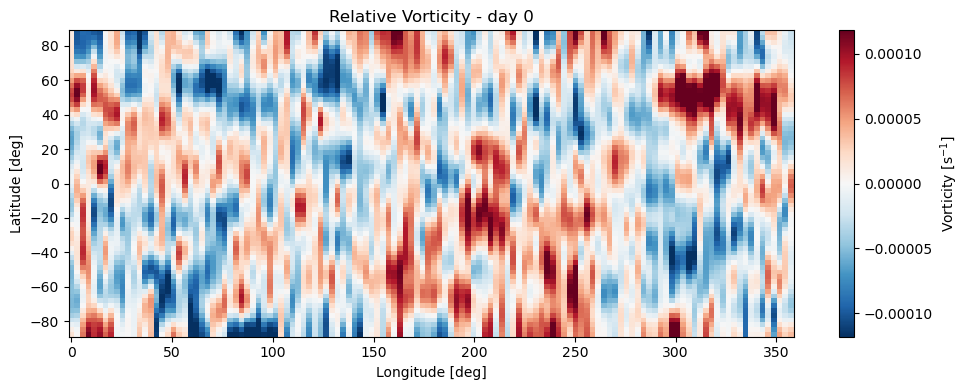

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))

vlim = np.percentile(np.abs(VOR_0), 98)
pc = ax.pcolormesh(lon, lat, VOR_0, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
plt.colorbar(pc, ax=ax, label='Vorticity [s$^{-1}$]')
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
ax.set_title('Relative Vorticity - day 0')
plt.tight_layout()
plt.show()

## 1.2 Streamfunction

**Motivation.** In 2D incompressible flow the streamfunction $\psi$ satisfies
$\nabla^2 \psi = \zeta$. This inversion suppresses small scales, so $\psi$ is
smoother than $\zeta$ and shows the large-scale flow structure more clearly.
Contour lines of $\psi$ are streamlines: the flow follows them exactly.
Closed contours indicate recirculation; open contours indicate jet-like throughflow.

This concept does not generalize to 3D or compressible flow, where a single
streamfunction does not exist.

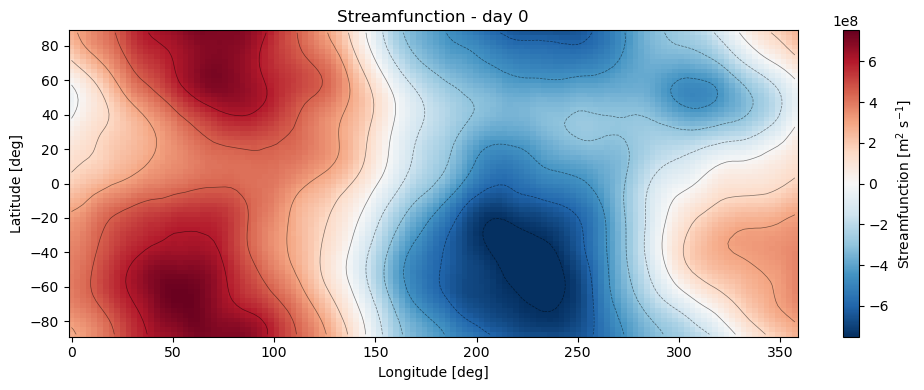

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))

vlim = np.percentile(np.abs(PSI_0), 98)
pc = ax.pcolormesh(lon, lat, PSI_0, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
plt.colorbar(pc, ax=ax, label='Streamfunction [m$^2$ s$^{-1}$]')
ax.contour(lon, lat, PSI_0, levels=12, colors='k', linewidths=0.5, alpha=0.5)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
ax.set_title('Streamfunction - day 0')
plt.tight_layout()
plt.show()

## 1.3 Zonal Mean Zonal Wind

**Motivation.** The zonal mean $[u](\phi) = \frac{1}{2\pi}\int_0^{2\pi} u\, d\lambda$
characterizes the background state of the atmosphere. In a barotropic stirring
experiment the central physical question is whether the stirring generates or
reinforces an eddy-driven jet. Plotting $[u]$ as a function of latitude at multiple
times on the same axis shows whether a jet is forming, strengthening, or shifting.

This diagnostic assumes zonal symmetry is a meaningful reduction, which is
specific to rotating-sphere atmospheric dynamics.

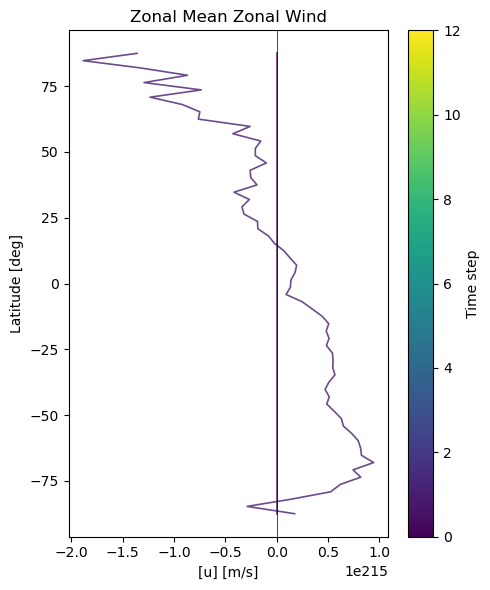

In [28]:
fig, ax = plt.subplots(figsize=(5, 6))

cmap = plt.cm.viridis
for t in range(NTIME):
    u_zonal = U_TS[t].mean(axis=1)
    ax.plot(u_zonal, lat, color=cmap(t / NTIME), alpha=0.8, linewidth=1.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, NTIME))
plt.colorbar(sm, ax=ax, label='Time step')
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('[u] [m/s]')
ax.set_ylabel('Latitude [deg]')
ax.set_title('Zonal Mean Zonal Wind')
plt.tight_layout()
plt.show()

## 1.4 Hovmoller Diagram

**Motivation.** A Hovmoller diagram is a latitude-vs-time map of the zonally averaged
zonal wind. It compresses the full space-time evolution into a single panel and makes
several phenomena visible at once: jet migration (slanted bands), spinup from rest,
low-frequency oscillations, and hemispheric symmetry breaking.

This is an atmospheric science convention, specific to systems where zonal averaging
is a meaningful reduction.

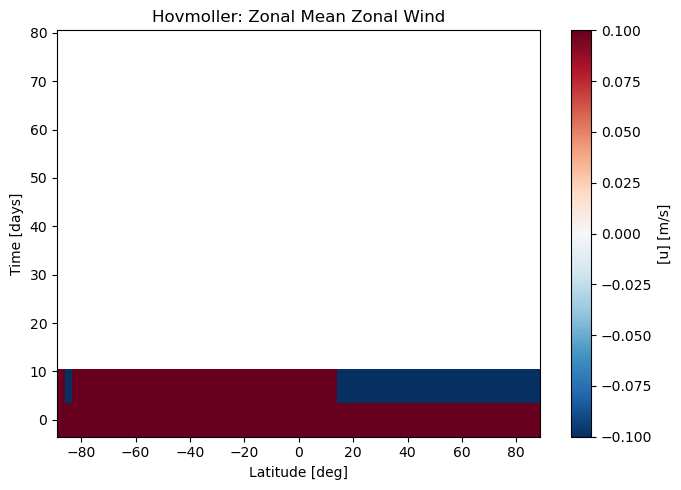

In [29]:
U_ZONAL = U_TS.mean(axis=2)  # (NTIME, NLAT)
days = np.arange(NTIME) * 7

fig, ax = plt.subplots(figsize=(7, 5))

vlim = np.percentile(np.abs(U_ZONAL), 99)
pc = ax.pcolormesh(lat, days, U_ZONAL, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
plt.colorbar(pc, ax=ax, label='[u] [m/s]')
ax.set_xlabel('Latitude [deg]')
ax.set_ylabel('Time [days]')
ax.set_title('Hovmoller: Zonal Mean Zonal Wind')
plt.tight_layout()
plt.show()

## 1.5 Enstrophy Conservation

**Motivation.** In the unforced barotropic model, enstrophy
$Z = \frac{1}{2}\int \zeta^2\, dA$ is exactly conserved alongside energy.
This is a special property of 2D flow and does not hold in 3D Navier-Stokes.
The dual conservation of energy and enstrophy forces the inverse energy cascade:
energy cannot move to small scales without enstrophy going there first,
and since enstrophy is bounded, energy must cascade upscale.

Tracking enstrophy over time diagnoses whether the model dissipates it correctly
and whether the stirring injects it at the intended scales.

/tmp/ipykernel_75855/780148880.py:1: RuntimeWarning: overflow encountered in square
  enstrophy = np.array([area_mean(0.5 * VOR[t] ** 2) for t in range(NTIME)])


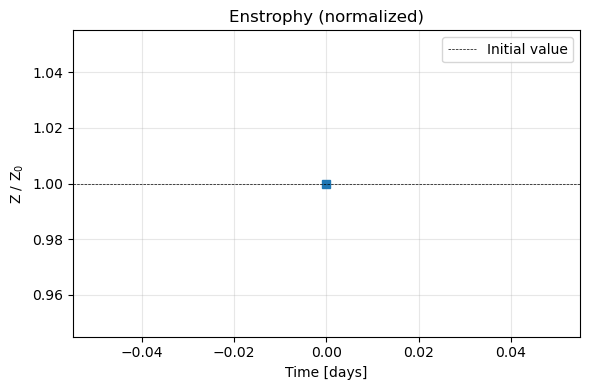

In [18]:
enstrophy = np.array([area_mean(0.5 * VOR[t] ** 2) for t in range(NTIME)])
days = np.arange(NTIME) * 7

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(days, enstrophy / enstrophy[0], 's-', linewidth=1.5)
ax.axhline(1.0, color='k', linewidth=0.5, linestyle='--', label='Initial value')
ax.set_xlabel('Time [days]')
ax.set_ylabel('Z / Z$_0$')
ax.set_title('Enstrophy (normalized)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 2: Fluid Dynamics General

These techniques apply to any fluid system, not just the BVE. They rely on
concepts that exist in Navier-Stokes, shallow water, primitive equation models,
and others: velocity fields, kinetic energy, and spectral decomposition of
turbulent flows. The specific interpretation (e.g., the reference spectral slope)
varies between systems, but the technique itself is reusable.

## 2.1 Wind / Velocity Quiver

**Motivation.** Any fluid system has a velocity field. Quiver plots show local
flow direction and magnitude simultaneously and are useful for verifying physical
consistency: do the vectors align with the streamfunction contours? Are there
unexpected regions of convergence or divergence?

Subsampling the grid is essential since plotting every point produces an unreadable
overplotted mess. Overlaying vectors on a scalar background connects direction
to dynamics.

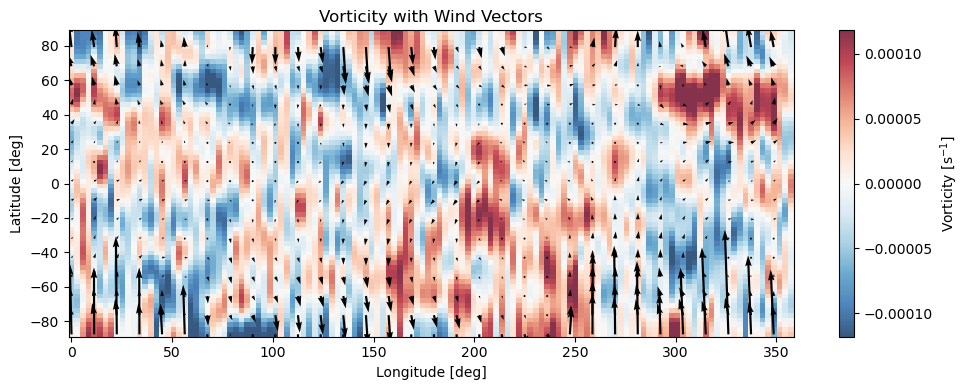

In [19]:
SKIP = 4  # plot every 4th grid point

fig, ax = plt.subplots(figsize=(10, 4))

vlim = np.percentile(np.abs(VOR_0), 98)
pc = ax.pcolormesh(lon, lat, VOR_0, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto', alpha=0.8)
plt.colorbar(pc, ax=ax, label='Vorticity [s$^{-1}$]')

# U_FULL and V_0 are derived consistently from the same streamfunction
u_sub = U_FULL[::SKIP, ::SKIP]
v_sub = V_0[::SKIP, ::SKIP]
scale = np.percentile(np.sqrt(u_sub**2 + v_sub**2), 95) * 20

ax.quiver(
    lon[::SKIP], lat[::SKIP],
    u_sub, v_sub,
    scale=scale, width=0.003, color='k'
)
ax.set_xlabel('Longitude [deg]')
ax.set_ylabel('Latitude [deg]')
ax.set_title('Vorticity with Wind Vectors')
plt.tight_layout()
plt.show()

## 2.2 Kinetic Energy Spectrum

**Motivation.** The kinetic energy spectrum $E(k)$ shows how energy is distributed
across spatial scales. It is a standard diagnostic for any turbulent fluid system.
The reference slope is system-dependent:

- 2D turbulence / BVE: $E(k) \sim k^{-3}$ (enstrophy cascade)
- 3D turbulence / Navier-Stokes: $E(k) \sim k^{-5/3}$ (Kolmogorov)

The technique itself generalizes to any fluid model. Computing it via zonal FFT
with area-weighting over latitude is the standard approach for spherical geometry.

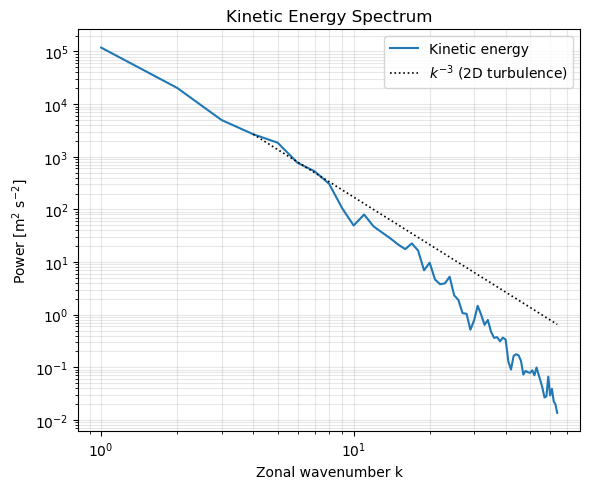

In [20]:
def zonal_energy_spectrum(u, cos_lat_weights):
    u_hat   = np.fft.rfft(u, axis=1)
    power   = (np.abs(u_hat) ** 2) / NLON
    weights = cos_lat_weights[:, None]
    return (power * weights).sum(axis=0) / weights.sum()

wavenumbers = np.arange(NLON // 2 + 1)
spectrum    = zonal_energy_spectrum(U_FULL, cos_weights)

k_ref = np.array([4, NLON // 2])
e_ref = spectrum[4] * (k_ref / 4.0) ** (-3)

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(wavenumbers[1:], spectrum[1:], linewidth=1.5, label='Kinetic energy')
ax.loglog(k_ref, e_ref, 'k:', linewidth=1.2, label='$k^{-3}$ (2D turbulence)')
ax.set_xlabel('Zonal wavenumber k')
ax.set_ylabel('Power [m$^2$ s$^{-2}$]')
ax.set_title('Kinetic Energy Spectrum')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 2.3 Kinetic Energy Conservation

**Motivation.** Any conservative fluid system conserves kinetic energy
$E = \frac{1}{2}\int(u^2 + v^2)\, dA$ in the absence of forcing and dissipation.
Tracking $E$ over time diagnoses numerical dissipation and verifies that forcing
and dissipation schemes behave as intended. In a stirred experiment energy should
grow; unexpected loss or non-monotonic behavior signals a numerical or
implementation problem.

/tmp/ipykernel_75855/4225336273.py:1: RuntimeWarning: overflow encountered in square
  energy = np.array([area_mean(0.5 * U_TS[t] ** 2) for t in range(NTIME)])


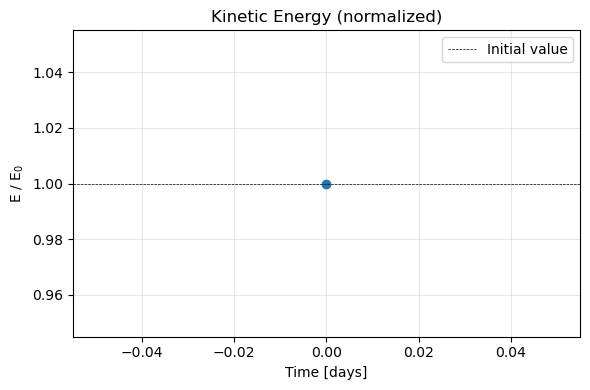

In [21]:
energy = np.array([area_mean(0.5 * U_TS[t] ** 2) for t in range(NTIME)])
days   = np.arange(NTIME) * 7

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(days, energy / energy[0], 'o-', linewidth=1.5)
ax.axhline(1.0, color='k', linewidth=0.5, linestyle='--', label='Initial value')
ax.set_xlabel('Time [days]')
ax.set_ylabel('E / E$_0$')
ax.set_title('Kinetic Energy (normalized)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 3: PDE General

These techniques apply to any PDE-based model or learned operator, regardless of
the physical system. They quantify how well a predicted field matches a reference
and whether the governing equations are satisfied. They are the standard toolkit
for evaluating neural operators, surrogate models, and emulators.

## 3.1 Error Maps

**Motivation.** Scalar error metrics (RMSE, MAE) collapse spatial structure into a
single number and hide where errors are located. Error maps answer different questions:

- **Absolute error** $|\hat{q} - q|$: where are the largest deviations?
- **Signed error** $\hat{q} - q$: are errors biased in specific regions?
- **Relative error** $|\hat{q} - q| / |q|$: does the model struggle where the signal
  is weak or where it is strong?

Overlaying error contours on the true field reveals whether errors cluster near
sharp gradients, which is physically meaningful and guides model improvement.

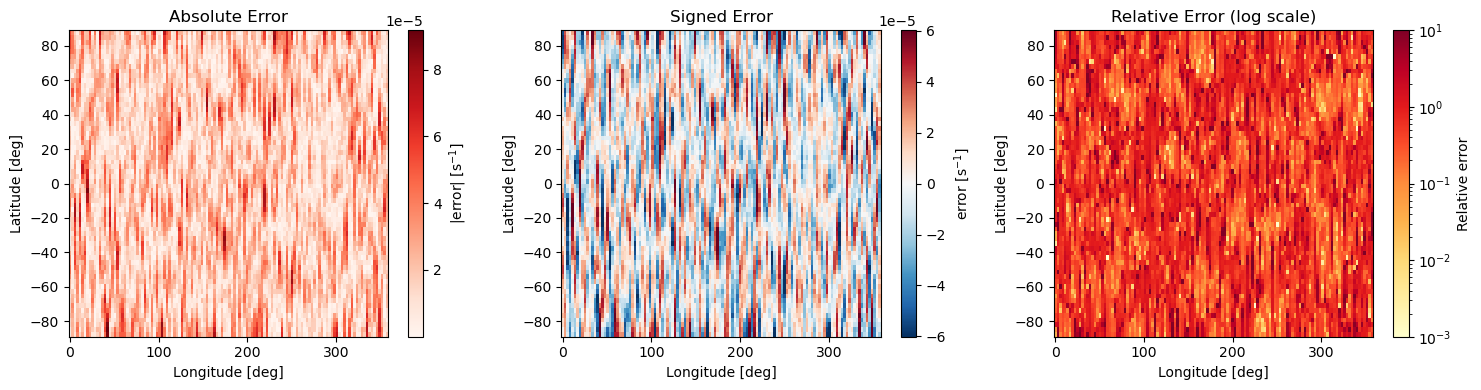

In [22]:
abs_error    = np.abs(VOR_PRED - VOR_TRUE)
signed_error = VOR_PRED - VOR_TRUE
rel_error    = abs_error / (np.abs(VOR_TRUE) + 1e-12 * np.abs(VOR_TRUE).max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pc0 = axes[0].pcolormesh(lon, lat, abs_error, cmap='Reds', shading='auto')
plt.colorbar(pc0, ax=axes[0], label='|error| [s$^{-1}$]')
axes[0].set_title('Absolute Error')

vlim = np.percentile(np.abs(signed_error), 98)
pc1 = axes[1].pcolormesh(lon, lat, signed_error, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
plt.colorbar(pc1, ax=axes[1], label='error [s$^{-1}$]')
axes[1].set_title('Signed Error')

rel_clipped = np.clip(rel_error, 1e-3, 10.0)
pc2 = axes[2].pcolormesh(lon, lat, rel_clipped, cmap='YlOrRd',
                          norm=mcolors.LogNorm(vmin=1e-3, vmax=10.0), shading='auto')
plt.colorbar(pc2, ax=axes[2], label='Relative error')
axes[2].set_title('Relative Error (log scale)')

for ax in axes:
    ax.set_xlabel('Longitude [deg]')
    ax.set_ylabel('Latitude [deg]')

plt.tight_layout()
plt.show()

## 3.2 Power Spectrum Comparison

**Motivation.** Comparing the power spectrum of a predicted field against the
reference reveals systematic spectral biases that pointwise error maps miss.
A model that scores well on RMSE may still be over-smoothing fine scales
(spectrum decays too fast) or amplifying noise (spectrum decays too slowly).

This is especially important for neural operators: the comparison shows which
wavenumbers the model has learned and which it has not, and guides hyperparameter
choices such as the number of Fourier modes in FNO.

Unlike the kinetic energy spectrum in Part 2, no physical reference slope is
needed here. The comparison is purely between prediction and truth.

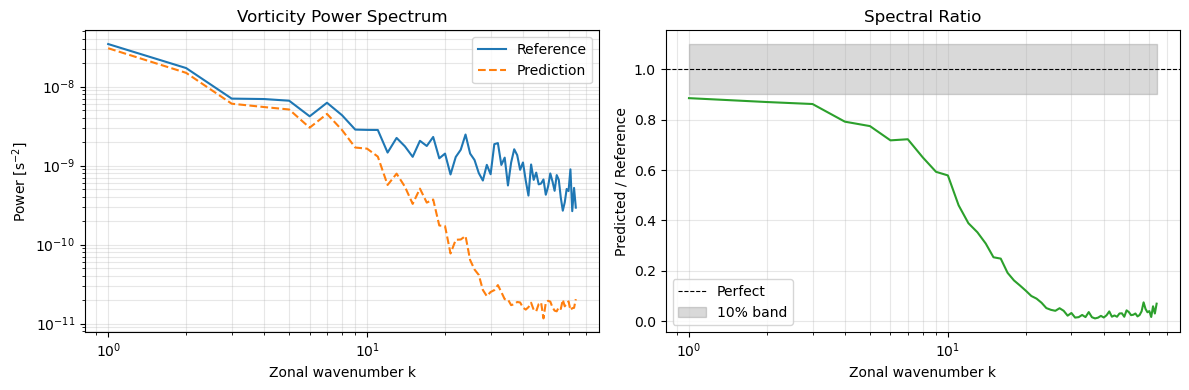

In [23]:
def power_spectrum(field, cos_lat_weights):
    f_hat   = np.fft.rfft(field, axis=1)
    power   = (np.abs(f_hat) ** 2) / field.shape[1]
    weights = cos_lat_weights[:, None]
    return (power * weights).sum(axis=0) / weights.sum()

wavenumbers = np.arange(NLON // 2 + 1)
spec_true   = power_spectrum(VOR_TRUE, cos_weights)
spec_pred   = power_spectrum(VOR_PRED, cos_weights)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(wavenumbers[1:], spec_true[1:], label='Reference', linewidth=1.5)
axes[0].loglog(wavenumbers[1:], spec_pred[1:], label='Prediction', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Zonal wavenumber k')
axes[0].set_ylabel('Power [s$^{-2}$]')
axes[0].set_title('Vorticity Power Spectrum')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

ratio = spec_pred[1:] / (spec_true[1:] + 1e-30)
axes[1].semilogx(wavenumbers[1:], ratio, linewidth=1.5, color='C2')
axes[1].axhline(1.0, color='k', linewidth=0.8, linestyle='--', label='Perfect')
axes[1].fill_between(wavenumbers[1:], 0.9, 1.1, alpha=0.15, color='k', label='10% band')
axes[1].set_xlabel('Zonal wavenumber k')
axes[1].set_ylabel('Predicted / Reference')
axes[1].set_title('Spectral Ratio')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## 3.3 PDE Residual Map

**Motivation.** A model can produce plausible-looking fields while violating the
governing equations. The PDE residual is the quantity that should be zero if the
solution is exact. For the BVE:

$$R = \frac{\partial \zeta}{\partial t} + u \frac{\partial \zeta}{\partial x} + v \frac{\partial \zeta}{\partial y} - F - D$$

The same idea applies to any PDE: compute the residual of the governing equation
using the predicted field and map where it is large.

Large residuals indicate physical inconsistency independently of whether the field
visually matches the reference. Overlaying residual contours on the field reveals
whether violations concentrate near sharp gradients or boundaries, which guides
model architecture and training strategy.

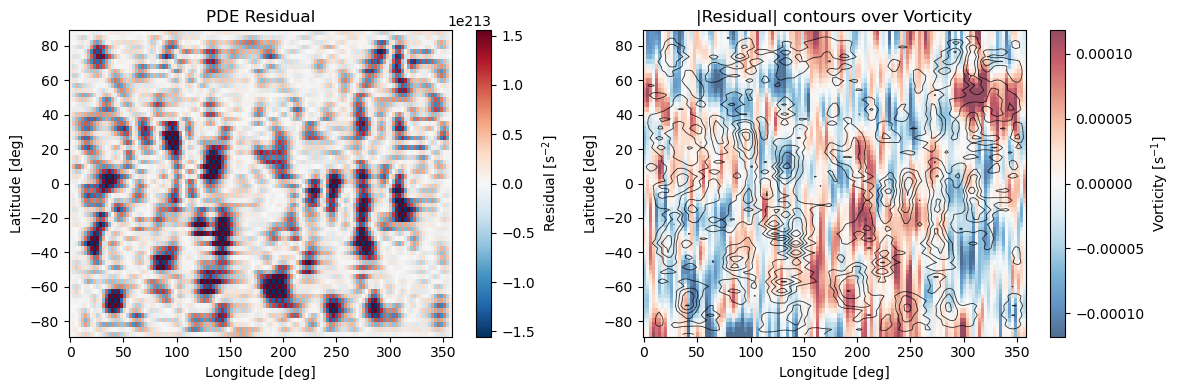

In [24]:
DT = 7.0 * 86400.0  # seconds per segment

dvdt      = (VOR[1] - VOR[0]) / DT
dvdx      = np.gradient(VOR[0], dlon, axis=1) / (EARTH_RADIUS * np.cos(LAT) + 1e-12)
advection = U_TS[0] * dvdx
residual  = dvdt - advection

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vlim = np.percentile(np.abs(residual), 98)
pc0 = axes[0].pcolormesh(lon, lat, residual, cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
plt.colorbar(pc0, ax=axes[0], label='Residual [s$^{-2}$]')
axes[0].set_title('PDE Residual')

vlim_v = np.percentile(np.abs(VOR[0]), 98)
pc1 = axes[1].pcolormesh(lon, lat, VOR[0], cmap='RdBu_r', vmin=-vlim_v, vmax=vlim_v, shading='auto', alpha=0.7)
plt.colorbar(pc1, ax=axes[1], label='Vorticity [s$^{-1}$]')
axes[1].contour(lon, lat, np.abs(residual), levels=5, colors='k', linewidths=0.6, alpha=0.8)
axes[1].set_title('|Residual| contours over Vorticity')

for ax in axes:
    ax.set_xlabel('Longitude [deg]')
    ax.set_ylabel('Latitude [deg]')

plt.tight_layout()
plt.show()

---
## Summary

| # | Visualization | Scope | What it shows |
|---|---|---|---|
| 1.1 | Vorticity snapshot | BVE | Instantaneous flow state |
| 1.2 | Streamfunction | BVE | Large-scale flow topology |
| 1.3 | Zonal mean [u] | BVE | Jet formation and evolution |
| 1.4 | Hovmoller | BVE | Space-time evolution of zonal mean |
| 1.5 | Enstrophy conservation | BVE | 2D invariant, dissipation check |
| 2.1 | Velocity quiver | Fluid dynamics | Flow direction and coherence |
| 2.2 | Kinetic energy spectrum | Fluid dynamics | Scale distribution, turbulence regime |
| 2.3 | Kinetic energy conservation | Fluid dynamics | Numerical integrity |
| 3.1 | Error maps | PDE general | Where predictions deviate and by how much |
| 3.2 | Power spectrum comparison | PDE general | Spectral fidelity of learned operator |
| 3.3 | PDE residual | PDE general | Physical consistency of predictions |